In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from flaml import AutoML

ImportError: cannot import name 'AutoML' from 'flaml' (c:\Users\LENOVO\Desktop\Internship_practice\myvenv\Lib\site-packages\flaml\__init__.py)

In [ ]:
PATH=r'C:\Users\LENOVO\Desktop\Internship_practice\Practice_intern\data\raw\Student Social Media And Mental Health Impact.csv'

In [ ]:
df=pd.read_csv(PATH)
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [ ]:
df.shape

(5000, 13)

In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [ ]:
df.describe


<bound method NDFrame.describe of       Age  Gender Country Academic_Level Most_Used_Platform Purpose_Of_Use  \
0      21    Male   Other  Undergraduate           Facebook     Networking   
1      23  Female   Other       Graduate           LinkedIn      Education   
2      22    Male  Canada  Undergraduate          Instagram  Entertainment   
3      18    Male   Other    High School           Snapchat  Entertainment   
4      24  Female   Other       Graduate           Facebook     Networking   
...   ...     ...     ...            ...                ...            ...   
4995   18  Female   Other    High School            YouTube      Education   
4996   18  Female   Other    High School            YouTube      Education   
4997   19  Female   India  Undergraduate           LinkedIn      Education   
4998   18    Male   Other    High School          Instagram  Entertainment   
4999   19    Male   China  Undergraduate             WeChat  Entertainment   

      Avg_Daily_Usage_Hours  

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

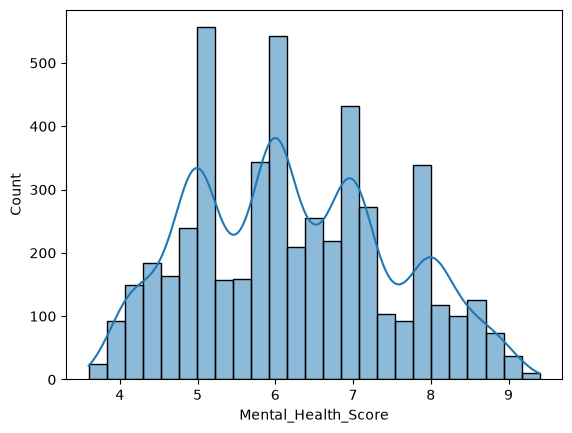

In [ ]:
sns.histplot(
    df['Mental_Health_Score'],
    kde=True
    )

<Axes: >

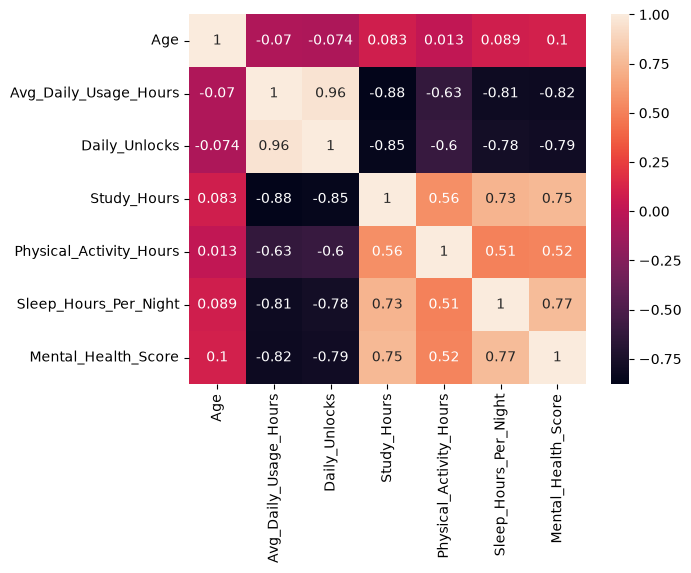

In [ ]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
    )

In [ ]:
df['Stress_Level'].unique()

<StringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

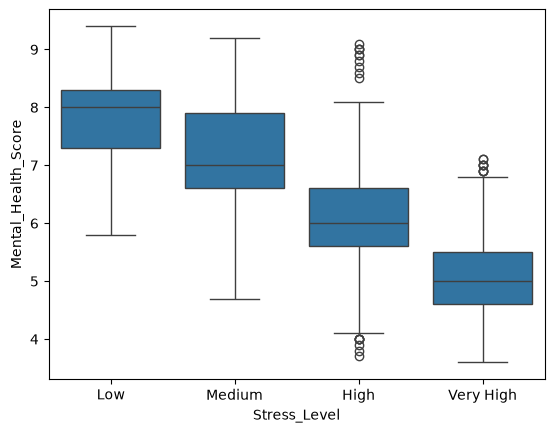

In [ ]:
order=['Low','Medium','High','Very High']
sns.boxplot(
    x='Stress_Level',
    y='Mental_Health_Score',
    data=df,
    order=order
)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

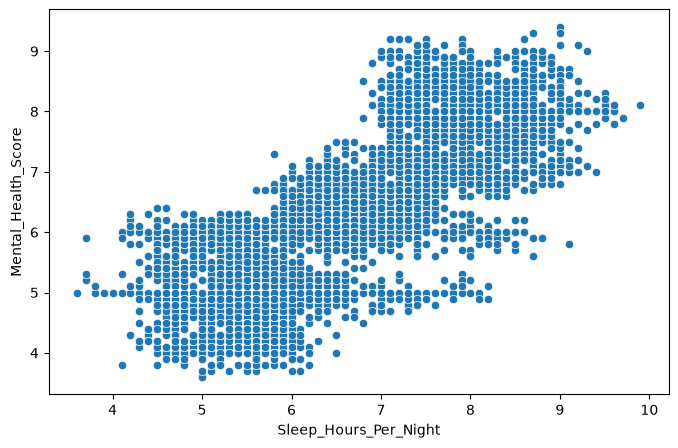

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Sleep_Hours_Per_Night',
    y='Mental_Health_Score',
    data=df
)

In [ ]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

Text(0.5, 1.0, 'Platform Usage')

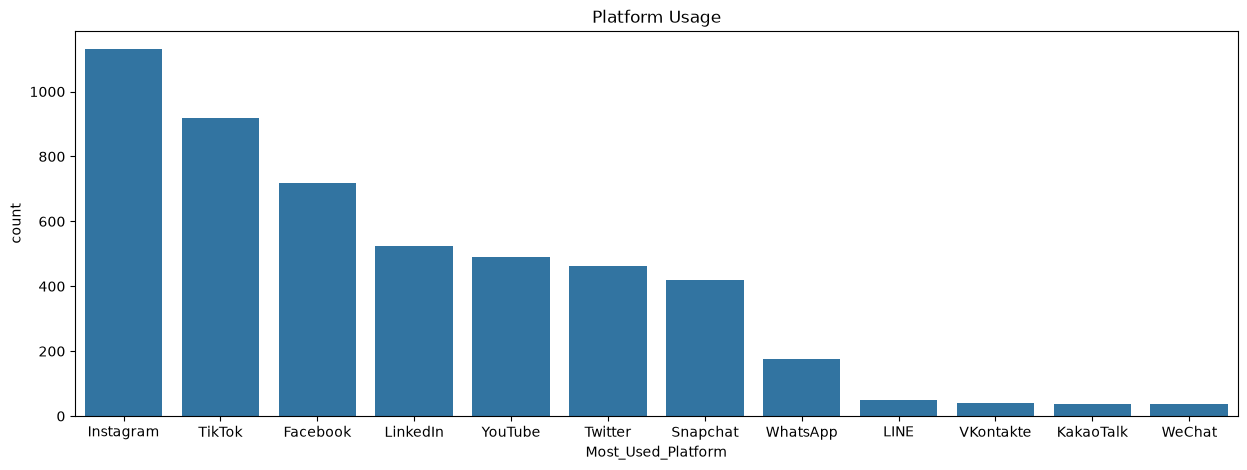

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(
    x='Most_Used_Platform',
    data=df,
    order=df['Most_Used_Platform'].value_counts().index
)
plt.title("Platform Usage")

Outliers handling

In [ ]:
num_features=df.select_dtypes(include='number')
Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)

IQR= Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR 

In [ ]:
outlier=(num_features<lower_bound) | (num_features>upper_bound)
outlier.sum()

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64

In [ ]:
df.describe
df[df.duplicated()==True]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [ ]:
df=df.drop_duplicates()
df[df.duplicated()==True]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4998.0,20.822129,1.736774,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,4998.0,5.078491,1.654097,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,4998.0,171.455582,42.859829,62.0,140.0,171.0,204.0,273.0
Study_Hours,4998.0,3.008403,1.636831,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,4998.0,1.750760,0.668406,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,4998.0,6.634654,1.221561,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,4998.0,6.231152,1.278476,3.6,5.1,6.1,7.1,9.4


In [ ]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4998.0,20.822129,1.736774,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,4998.0,5.078491,1.654097,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,4998.0,171.455582,42.859829,62.0,140.0,171.0,204.0,273.0
Study_Hours,4998.0,3.008403,1.636831,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,4998.0,1.751160,0.667282,0.0,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,4998.0,6.634654,1.221561,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,4998.0,6.231152,1.278476,3.6,5.1,6.1,7.1,9.4
